# utils

In [1]:
import pandas as pd
import os
import random
import chardet
import requests
import json
import numpy as np
from urllib3.util.retry import Retry
import openai
from requests.adapters import HTTPAdapter
import os
import pickle
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from copy import deepcopy

/home/lzs/miniconda3/envs/lzs/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (1.26.15) or chardet (7.3.0)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import os

font_path = '/mnt/dataset0/lzs/.fonts/arial.ttf'  # 1) 路径要确认存在
assert os.path.exists(font_path), f"字体文件不存在: {font_path}"

# 2) 注册字体到 Matplotlib 的 fontManager（关键！）
fm.fontManager.addfont(font_path)

# 3) 读取这份 ttf 的“内部字体名”（可能是 Arial / ArialMT 等）
font_name = fm.FontProperties(fname=font_path).get_name()
print("Internal font name =", font_name)

# 4) 彻底避免去找 'Arial' 这个字符串
mpl.rcParams['font.family'] = [font_name]       # 用内部名
mpl.rcParams['font.sans-serif'] = [font_name]   # 避免回退到其他 sans-serif
mpl.rcParams['axes.unicode_minus'] = False

Internal font name = Arial


In [3]:

with open('data/danmu_Forrest_drop_first_1pct_users_downsample.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
    print(danmu_dict.keys())
    print(len(danmu_dict['Forrest_drop_first_1pct_users.csv_time_range']))
    print(len(danmu_dict['Forrest_drop_first_1pct_users.csv']))


dict_keys(['Forrest_drop_first_1pct_users.csv', 'Forrest_drop_first_1pct_users.csv_time_range'])
5197
5197


In [4]:
def read_scores(file, seg_count,datadir='results/prompt_v4',pkl_dir='data/n_danmu_per_group20_flexwindow/danmu_Forrest_Gump_downsample_No_Time_To_Die_flexwindow.pkl'):
    file_name = file.split('.')[0]
    with open(pkl_dir, 'rb') as f:
        danmu_dict = pickle.load(f)
    time_ranges = danmu_dict['%s.csv_time_range' % file]
    
    time_points = np.zeros(len(time_ranges))
    for i in range(len(time_points)):
        time_points[i] = np.mean(time_ranges[i])
    file_names2 = os.listdir(datadir)
    n_files = len(file_names2)
    if n_files != seg_count:
        Warning('The number of files is not equal to segment counts!')
        print('n_files:', n_files, 'seg_count:', seg_count)
    scores_all = np.zeros((seg_count, 6))
    for count in range(seg_count):
        # print(count)
        file_score = '%.3f_%.3f.json' % (time_ranges[count][0], time_ranges[count][1])
        with open(os.path.join(datadir, file_score), 'r', encoding='utf-8') as file_score:
            data = json.load(file_score)            

        # 提取 "content" 字段中的文本
        content = data['choices'][0]['message']['content']

        # 解析文本，将情绪评分提取到列表中
        emotions = ["高兴", "惊讶", "悲伤", "愤怒", "厌恶", "恐惧"]
        scores = []

        # 拆分 content 字符串，并提取每个情绪的评分
        for emotion in emotions:
            start = content.find(emotion) + len(emotion) + 2
            end = content.find(";", start)
            if end == -1:  # 最后一个情绪评分后没有分号
                end = len(content)
            # score = int(content[start:end].strip().rstrip('.'))
            # score = int(content[start:end].strip())
            try:
                score = float(content[start:end].strip())
            except:
                if content[start] == '[':
                    score = float(content[start+1:end-1].strip())
                else:
                    score = float(content[start:end].strip()[:-1])
            scores.append(score)
            
        scores_all[count] = np.array(scores)
        
    return scores_all, time_points


def read_scores_bysecond(file):
    file_name = file.split('.')[0]
    failed_counts = []
    with open('data/n_danmu_per_group20_fixwindow/danmu_%s_downsample_fixwindow.pkl' % file_name, 'rb') as f:
        danmu_dict = pickle.load(f)
    time_ranges = danmu_dict['%s.csv_time_range' % file]
    
    time_points_max = int(np.mean(time_ranges[-1]))
    time_points = np.arange(time_points_max+1)
    print('time length:', time_points_max)

    datadir = os.path.join('results/prompt_v4', file_name)

    scores_all = np.zeros((time_points_max+1, 6))
    for count in range(time_points_max+1):
        print(time_ranges[count][0], time_ranges[count][1])
        file_score = '%.3f_%.3f.json' % (time_ranges[count][0], time_ranges[count][1])
        if not os.path.exists(os.path.join(datadir, file_score)):
            scores_all[count] = [None, None, None, None, None, None]
        else:
            try:
                with open(os.path.join(datadir, file_score), 'r', encoding='utf-8') as file_score:
                    data = json.load(file_score)            

                # 提取 "content" 字段中的文本
                content = data['choices'][0]['message']['content']

                # 解析文本，将情绪评分提取到列表中
                emotions = ["高兴", "惊讶", "悲伤", "愤怒", "厌恶", "恐惧"]
                scores = []

                # 拆分 content 字符串，并提取每个情绪的评分
                for emotion in emotions:
                    start = content.find(emotion) + len(emotion) + 2
                    end = content.find(";", start)
                    if end == -1:  # 最后一个情绪评分后没有分号
                        end = len(content)
                    # score = int(content[start:end].strip().rstrip('.'))
                    # score = int(content[start:end].strip())
                    try:
                        score = float(content[start:end].strip())
                    except:
                        if content[start] == '[':
                            score = float(content[start+1:end-1].strip())
                        else:
                            score = float(content[start:end].strip()[:-1])
                    scores.append(score)
            except Exception as e:
                # 捕获所有异常（JSON错误、KeyError、IndexError等）
                print(f"Error processing count {count}: {e}")
                failed_counts.append(count)
                scores_all[count] = [np.nan] * 6  # 使用 NaN 而不是 None，便于后续 numpy 处理
                continue
                
            scores_all[count] = np.array(scores)
        
    return scores_all, time_points, failed_counts


def smooth_scores(preds, time_points, smooth_win=10):
    half_win = int(round(smooth_win/2))
    preds_smoothed = np.zeros(preds.shape)
    for i in range(preds.shape[0]):
        preds_smoothed[i,:] = np.nanmean(preds[abs(time_points[:preds.shape[0]] - time_points[:preds.shape[0]][i]) <= half_win, :], axis=0)
    return preds_smoothed
        

def plot_scores(preds_smoothed, time_points):
    colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
    emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]

    plt.figure(figsize=(15, 12))
    for j in range(6):
        plt.subplot(6,1,j+1)
        plt.plot(time_points[:preds_smoothed.shape[0]], preds_smoothed[:,j], color=colors[j], linewidth=0.7)
        plt.xlim([0,max(time_points)])
        plt.ylim([0,7])
        plt.ylabel('Scores')
        plt.xlabel('Time/s')
        plt.title(emos[j])

    # 调整布局
    plt.tight_layout()
    # plt.savefig('figures/prompt_v4_gpt4o_longMovie_lineplot.jpg', dpi=300)
    plt.show()

# original LLM score

In [5]:
with open('data/danmu_Forrest_drop_first_1pct_users_downsample.pkl', 'rb') as f:
        danmu_dict = pickle.load(f)
        print(danmu_dict.keys())
        print(len(danmu_dict['Forrest_drop_first_1pct_users.csv_time_range']))

dict_keys(['Forrest_drop_first_1pct_users.csv', 'Forrest_drop_first_1pct_users.csv_time_range'])
5197


In [6]:
with open('data/danmu_Forrest_drop_first_1pct_users_downsample.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
len(danmu_dict['Forrest_drop_first_1pct_users.csv_time_range'])

5197

In [7]:
seg_count = len(danmu_dict['Forrest_drop_first_1pct_users.csv_time_range'])
scores_flexwindow, time_points_flexwindow = read_scores('Forrest_drop_first_1pct_users', seg_count,
                                                        pkl_dir='data/danmu_Forrest_drop_first_1pct_users_downsample.pkl'
                                                        ,datadir='results/prompt_lzs/Forrest_drop_first_1pct_users')

n_files: 8506 seg_count: 5197


In [8]:
with open(r'/mnt/dataset1/xinke/Danmu/DyEmo-film/Emotion_scores/scores_longMovie_gpt3_5_turbo.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
print(scores_allvideo.keys())
preds = scores_allvideo['forrest_gump']
print(preds.shape)
with open(r'/mnt/dataset1/xinke/Danmu/DyEmo-film/Processed_danmu/movie_batch1/danmu_forrest_gump_downsample.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
time_ranges = danmu_dict['forrest_gump.csv_time_range']

# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_ranges))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_ranges[i])
# Find time points in the original movie (time points are for bilibili version, which cut 4 segments)

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,6))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, 6))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over ts windows
smooth_win = 10
preds_smoothed = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
    preds_smoothed[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)

dict_keys(['error_count_list', 'forrest_gump'])
(5756, 6)


# valence arousal

In [9]:
import os
import re
import json
import pickle
import numpy as np


def parse_va_scores(content):
    patterns = {
        "valence": r"效价\s*[:：=]\s*\[?\s*(-?\d+(?:\.\d+)?)\s*\]?",
        "arousal": r"(?:唤醒|唤起)\s*[:：=]\s*\[?\s*(-?\d+(?:\.\d+)?)\s*\]?"
    }

    valence_match = re.search(patterns["valence"], content)
    arousal_match = re.search(patterns["arousal"], content)

    if valence_match is None or arousal_match is None:
        raise ValueError(f"无法解析 content: {content}")

    valence = float(valence_match.group(1))
    arousal = float(arousal_match.group(1))

    return np.array([arousal, valence])


def read_scores_va(
    file,
    seg_count,
    datadir='results/prompt_v4',
    pkl_dir='data/n_danmu_per_group20_flexwindow/danmu_Forrest_Gump_downsample_No_Time_To_Die_flexwindow.pkl'
): 
    with open(pkl_dir, 'rb') as f:
        danmu_dict = pickle.load(f)

    time_ranges = danmu_dict[f'{file}.csv_time_range']

    time_points = np.zeros(len(time_ranges))
    for i in range(len(time_points)):
        time_points[i] = np.mean(time_ranges[i])

    file_names2 = os.listdir(datadir)
    n_files = len(file_names2)

    if n_files != seg_count:
        print('Warning: The number of files is not equal to segment counts!')
        print('n_files:', n_files, 'seg_count:', seg_count)

    scores_all = np.zeros((seg_count, 2))

    for count in range(seg_count):
        file_score_name = '%.3f_%.3f.json' % (
            time_ranges[count][0],
            time_ranges[count][1]
        )

        file_score_path = os.path.join(datadir, file_score_name)

        with open(file_score_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        content = data['choices'][0]['message']['content']

        try:
            scores_all[count] = parse_va_scores(content)
        except ValueError as e:
            print(f"解析失败: {file_score_path}")
            print(e)
            scores_all[count] = np.array([np.nan, np.nan])

    return scores_all, time_points

In [10]:
seg_count = len(os.listdir('results/prompt_lzs/valence_arousal/forrest_gump_explain_prompt'))
scores_flexwindow, time_points_flexwindow = read_scores_va('forrest_gump', seg_count,
                                                        pkl_dir='/mnt/dataset1/xinke/Danmu/DyEmo-submit/DyEmo-Forrest/Processed_danmu/danmu_Forrest_Gump_downsample.pkl'
                                                        ,datadir='results/prompt_lzs/valence_arousal/forrest_gump_explain_prompt')

In [11]:
# cut predicted scores and time_points_german into 8 runs

cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_points_flexwindow))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_points_flexwindow[i])
# Find time points in the original movie (time points are for bilibili version, which cut 4 segments)

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,2))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, scores_flexwindow[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, 2))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over ts windows
smooth_win = 10
preds_smoothed_va = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
    preds_smoothed_va[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)

In [12]:
from sklearn.decomposition import PCA
import matplotlib
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(preds_all)

# 创建PCA对象，设定要保留的主成分数量（例如：2个主成分）
pca = PCA(n_components=6)

# 使用PCA降维
X_pca = pca.fit_transform(preds_smoothed)

r_mat = []
p_mat = []

print('valence')
for i in range(6):
    r, p = pearsonr(preds_smoothed_va[:,1], X_pca[:,i])
    r_mat.append(r)
    p_mat.append(p)
    print(f'PC{i+1}: r={r:.3f}, p={p}')
print('------------------')
print('arousal')
for i in range(6):
    r, p = pearsonr(preds_smoothed_va[:,0], X_pca[:,i])
    r_mat.append(r)
    p_mat.append(p)
    print(f'PC{i+1}: r={r:.3f}, p={p}')


valence
PC1: r=-0.792, p=0.0
PC2: r=0.425, p=1.3000265846166017e-157
PC3: r=0.109, p=6.735631370382598e-11
PC4: r=-0.031, p=0.06700779711917107
PC5: r=-0.063, p=0.00016062090062686678
PC6: r=-0.088, p=1.2137707293160417e-07
------------------
arousal
PC1: r=-0.391, p=5.802651415007854e-132
PC2: r=0.066, p=7.82248762892317e-05
PC3: r=0.362, p=1.2812891199634967e-111
PC4: r=0.111, p=2.080784090227925e-11
PC5: r=0.042, p=0.01107806495379377
PC6: r=-0.058, p=0.000543759989738268


In [13]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.decomposition import PCA

emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]

def circular_shift_perm_corr(x, y, n_perm=10000, seed=42, two_sided=True):
    x = np.asarray(x)
    y = np.asarray(y)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    n = len(x)
    if n < 3:
        raise ValueError("Need at least 3 valid time points.")

    r_obs, _ = pearsonr(x, y)

    rng = np.random.default_rng(seed)

    # exclude lag=0 because it is the original alignment
    lags = rng.integers(1, n, size=n_perm)

    null_rs = np.empty(n_perm)
    for i, lag in enumerate(lags):
        y_shifted = np.roll(y, lag)
        null_rs[i], _ = pearsonr(x, y_shifted)

    if two_sided:
        p_perm = (np.sum(np.abs(null_rs) >= np.abs(r_obs)) + 1) / (n_perm + 1)
    else:
        if r_obs >= 0:
            p_perm = (np.sum(null_rs >= r_obs) + 1) / (n_perm + 1)
        else:
            p_perm = (np.sum(null_rs <= r_obs) + 1) / (n_perm + 1)

    return r_obs, p_perm, null_rs


# PCA
pca = PCA(n_components=6)
X_pca = pca.fit_transform(preds_smoothed)
flip_idx = [0, 3, 4]  # PC1, PC4, PC5

X_pca[:, flip_idx] *= -1
pca.components_[flip_idx, :] *= -1
r_mat = []
p_mat = []

print("valence")
for i in range(6):
    r, p, null_rs = circular_shift_perm_corr(
        preds_smoothed_va[:, 1],
        X_pca[:, i],
        n_perm=10000,
        seed=42 + i,
        two_sided=True
    )
    r_mat.append(r)
    p_mat.append(p)
    print(f"PC{i+1}: r={r:.3f}, circular-shift p={p:.3e}")

print("------------------")

print("arousal")
for i in range(6):
    r, p, null_rs = circular_shift_perm_corr(
        preds_smoothed_va[:, 0],
        X_pca[:, i],
        n_perm=10000,
        seed=142 + i,
        two_sided=True
    )
    r_mat.append(r)
    p_mat.append(p)
    print(f"PC{i+1}: r={r:.3f}, circular-shift p={p:.3e}")

valence
PC1: r=0.792, circular-shift p=9.999e-05
PC2: r=0.425, circular-shift p=9.999e-05
PC3: r=0.109, circular-shift p=1.070e-01
PC4: r=0.031, circular-shift p=6.666e-01
PC5: r=0.063, circular-shift p=2.211e-01
PC6: r=-0.088, circular-shift p=9.189e-02
------------------
arousal
PC1: r=0.391, circular-shift p=9.999e-05
PC2: r=0.066, circular-shift p=4.325e-01
PC3: r=0.362, circular-shift p=9.999e-05
PC4: r=-0.111, circular-shift p=1.753e-01
PC5: r=-0.042, circular-shift p=4.484e-01
PC6: r=-0.058, circular-shift p=2.718e-01


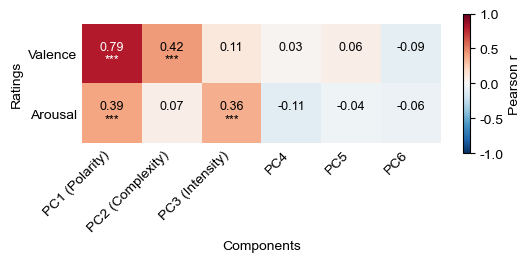

In [14]:

r_mat = np.array(r_mat).reshape(2,6)
p_mat = np.array(p_mat).reshape(2,6)

row_labels = ['Valence','Arousal']
col_labels = ['PC1 (Polarity)', 'PC2 (Complexity)', 'PC3 (Intensity)', 'PC4', 'PC5', 'PC6']

# ---------------------------
# 显著性星号函数
# ---------------------------
def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# ---------------------------
# 画图
# ---------------------------
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(5.5, 2.6))

im = ax.imshow(r_mat, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_aspect(1.0)

# 坐标轴
ax.set_xticks(np.arange(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha='right')
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)

ax.set_xlabel('Components')
ax.set_ylabel('Ratings')

# 去掉边框
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='both', length=0)

# 在格子里写数值 + 显著性
for i in range(r_mat.shape[0]):
    for j in range(r_mat.shape[1]):
        r = r_mat[i, j]
        p = p_mat[i, j]
        stars = p_to_star(p)

        # 根据底色深浅自动换字颜色
        text_color = 'white' if abs(r) > 0.45 else 'black'

        ax.text(j, i, f'{r:.2f}\n{stars}',
                ha='center', va='center',
                color=text_color, fontsize=9)

# colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Pearson r')

plt.tight_layout()
plt.savefig('figures/pca_valence_arousal_corr.svg', dpi=300, bbox_inches='tight')
plt.show()

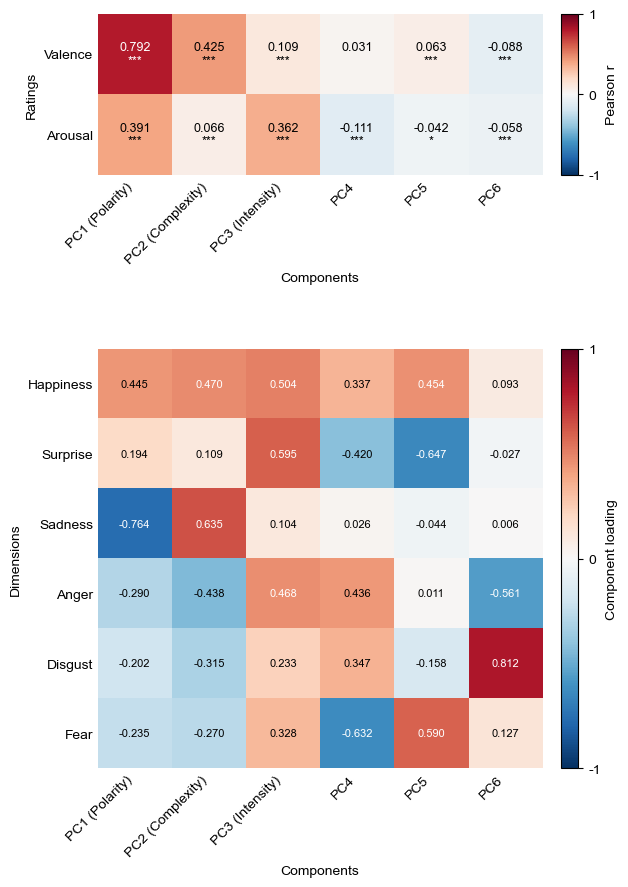

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# =========================
# 基础设置
# =========================
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['font.family'] = 'Arial'

emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
pc_labels = ['PC1 (Polarity)', 'PC2 (Complexity)', 'PC3 (Intensity)', 'PC4', 'PC5', 'PC6']
row_labels = ['Valence', 'Arousal']

# =========================
# 1) PCA
# =========================
pca = PCA(n_components=6)
X_pca = pca.fit_transform(preds_smoothed)
flip_idx = [0, 3, 4]  # PC1, PC4, PC5

X_pca[:, flip_idx] *= -1
pca.components_[flip_idx, :] *= -1

# 如果你想统一符号方向，可在这里手动翻转
components = pca.components_.copy()

# # 例子：让 PC1 与 valence 正相关
# r_tmp, _ = pearsonr(preds_smoothed_va[:, 1], X_pca[:, 0])
# if r_tmp < 0:
#     X_pca[:, 0] *= -1
#     components[0, :] *= -1

# # 例子：让 PC3 与 arousal 正相关（可选）
# r_tmp, _ = pearsonr(preds_smoothed_va[:, 0], X_pca[:, 2])
# if r_tmp < 0:
#     X_pca[:, 2] *= -1
#     components[2, :] *= -1

# component matrix: 行=emotion，列=PC
comp_mat = components.T

# =========================
# 2) 计算 r_mat / p_mat
# =========================
r_mat = np.zeros((2, 6))
p_mat = np.zeros((2, 6))

# Valence
for i in range(6):
    r, p = pearsonr(preds_smoothed_va[:, 1], X_pca[:, i])
    r_mat[0, i] = r
    p_mat[0, i] = p

# Arousal
for i in range(6):
    r, p = pearsonr(preds_smoothed_va[:, 0], X_pca[:, i])
    r_mat[1, i] = r
    p_mat[1, i] = p

# =========================
# 3) 显著性星号函数
# =========================
def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# =========================
# 4) 作图：上下拼接，严格对齐
# =========================
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(6.2, 9.8))

gs = GridSpec(
    2, 2,
    figure=fig,
    width_ratios=[20, 0.8],      # 左边 heatmap，右边 colorbar
    height_ratios=[1.0, 2.6],    # 上图和下图高度比例
    hspace=0.6,                # 上下间距
    wspace=0.08                 # heatmap 和 colorbar 间距
)

ax1 = fig.add_subplot(gs[0, 0])
cax1 = fig.add_subplot(gs[0, 1])

ax2 = fig.add_subplot(gs[1, 0])
cax2 = fig.add_subplot(gs[1, 1])

# ---------- 上图：valence / arousal correlation ----------
im1 = ax1.imshow(r_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax1.set_xticks(np.arange(len(pc_labels)))
ax1.set_xticklabels(pc_labels, rotation=45, ha='right')
ax1.set_yticks(np.arange(len(row_labels)))
ax1.set_yticklabels(row_labels)

ax1.set_xlabel('Components')
ax1.set_ylabel('Ratings')

for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.tick_params(axis='both', length=0)

for i in range(r_mat.shape[0]):
    for j in range(r_mat.shape[1]):
        r = r_mat[i, j]
        p = p_mat[i, j]
        stars = p_to_star(p)
        text_color = 'white' if abs(r) > 0.45 else 'black'
        ax1.text(
            j, i, f'{r:.3f}\n{stars}',
            ha='center', va='center',
            color=text_color, fontsize=9
        )

cbar1 = fig.colorbar(im1, cax=cax1)
cbar1.set_label('Pearson r')
cbar1.set_ticks([-1, 0, 1])

# ---------- 下图：PCA component heatmap ----------
max_abs = np.max(np.abs(comp_mat))
im2 = ax2.imshow(comp_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax2.set_xticks(np.arange(len(pc_labels)))
ax2.set_xticklabels(pc_labels, rotation=45, ha='right')
ax2.set_yticks(np.arange(len(emos)))
ax2.set_yticklabels(emos)

ax2.set_xlabel('Components')
ax2.set_ylabel('Dimensions')

for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.tick_params(axis='both', length=0)

for i in range(comp_mat.shape[0]):
    for j in range(comp_mat.shape[1]):
        val = comp_mat[i, j]
        text_color = 'white' if abs(val) > 0.45 else 'black'
        ax2.text(
            j, i, f'{val:.3f}',
            ha='center', va='center',
            color=text_color, fontsize=8
        )

cbar2 = fig.colorbar(im2, cax=cax2)
cbar2.set_label('Component loading')
cbar2.set_ticks([-1, 0, 1])

plt.savefig('figures/supfig_pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()